In [1]:
%pip install --upgrade face_recognition
%pip install ultralytics

import os
import numpy as np
import cv2
import face_recognition
from ultralytics import YOLO

import matplotlib.pyplot as plt
import glob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=77e93d5eab48dbe129a823385b882104a874eb17bc35b293a7e3bc5013d53f75
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
model = YOLO('yolov8n.pt')
THRESHOLD = 0.45
MIN_FACE_SIZE = 40

known_encodings = []
known_names = []

In [3]:
def normalize(v):
    return v / np.linalg.norm(v)

In [21]:
def load_dataset(dataset_path):
    for person_name in os.listdir(dataset_path):
        plt.figure(figsize=(8,8))

        person_path = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_path):
            continue

        encodings = []
        files = glob.glob(f"{person_path}/*.jpeg")
        for i, file in enumerate(files):
            image = face_recognition.load_image_file(file)
            faces = face_recognition.face_encodings(image)
            if faces:
                encodings.append(faces[0])

                plt.subplot(1, len(files), i + 1)
                plt.imshow(image)
                plt.title(person_name)
                plt.axis("off")

        if encodings:
            mean_encoding = np.mean(encodings, axis=0)

            known_encodings.append(normalize(mean_encoding))
            known_names.append(person_name)

In [8]:
def recognize(frame):
    results = model(frame)

    for result in results:
        for box in result.boxes:
            if int(box.cls) != 0:
                continue

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            pessoa = frame[y1:y2, x1:x2]
            rgb = cv2.cvtColor(pessoa, cv2.COLOR_BGR2RGB)
            locations = face_recognition.face_locations(rgb)
            if not locations:
                continue

            encodings = face_recognition.face_encodings(rgb, locations)
            for encoding, (top, right, bottom, left) in zip(encodings, locations):
                if (right-left) < MIN_FACE_SIZE:
                    continue

                encoding = normalize(encoding)

                distances = np.linalg.norm(
                    np.array(known_encodings) - encoding,
                    axis=1
                )

                best_match = np.argmin(distances)
                best_distance = distances[best_match]

                similarity = (1 - best_distance) * 100

                name = "Desconhecido"

                if best_distance < THRESHOLD:
                    name = known_names[best_match]

                    # escolher cor pela confiança
                if similarity > 70:
                    color = (0,255,0)   # verde
                elif similarity > 50:
                    color = (0,165,255) # laranja
                else:
                    color = (0,0,255)   # vermelho

                top += y1
                bottom += y1
                left += x1
                right += x1

                label = f"{name} {similarity:.1f}%"

                cv2.rectangle(frame,(left,top),(right,bottom),color,2)

                cv2.putText(
                    frame,
                    label,
                    (left, top-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    (0,255,0),
                    2
                )

    return frame


0: 640x448 1 person, 166.9ms
Speed: 5.5ms preprocess, 166.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 448)

0: 640x384 1 person, 172.9ms
Speed: 4.0ms preprocess, 172.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 384)


(np.float64(-0.5), np.float64(1055.5), np.float64(1599.5), np.float64(-0.5))

<Figure size 800x800 with 0 Axes>

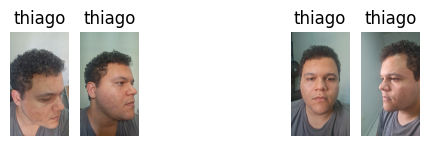

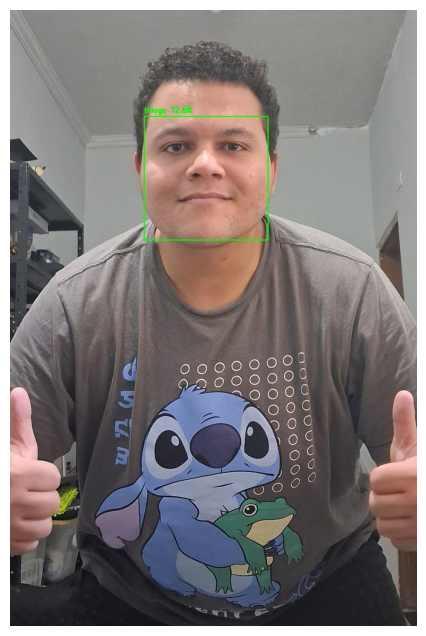

In [45]:
# carregar dataset
load_dataset("/content/dataset")

# testar imagem
frame_green = cv2.imread("/content/valido.jpeg")
result_similar = recognize(frame_green)

frame_red = cv2.imread("/content/erro.jpeg")
result_not_similar = recognize(frame_red)

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(result_similar, cv2.COLOR_BGR2RGB))
plt.axis("off")